In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [17]:
df = pd.read_csv('../data/processed/ipl_features.csv')

df.head()

,batting_team,bowling_team,venue,toss_winner,toss_decision,team1_win_pct,team2_win_pct,toss_win_match_win,target
0,6,14,23,14,1,0.502793,0.475992,0,1
1,14,6,23,14,1,0.475992,0.502793,0,0
2,0,4,41,0,0,0.561404,0.447368,1,1
3,4,0,41,0,0,0.447368,0.561404,1,0
4,11,1,16,11,0,0.492693,0.445269,0,0


In [35]:

encoders = {}

categorical_cols = ['batting_team','bowling_team','venue','toss_winner','toss_decision']

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(df[col])  # ✅ FIT ONLY
    df[col] = le.transform(df[col])
    encoders[col] = le

In [20]:
X = df.drop('target', axis=1)
y = df['target']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [22]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [23]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9180672268907563

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.92       242
           1       0.91      0.92      0.92       234

    accuracy                           0.92       476
   macro avg       0.92      0.92      0.92       476
weighted avg       0.92      0.92      0.92       476


Confusion Matrix:
 [[221  21]
 [ 18 216]]


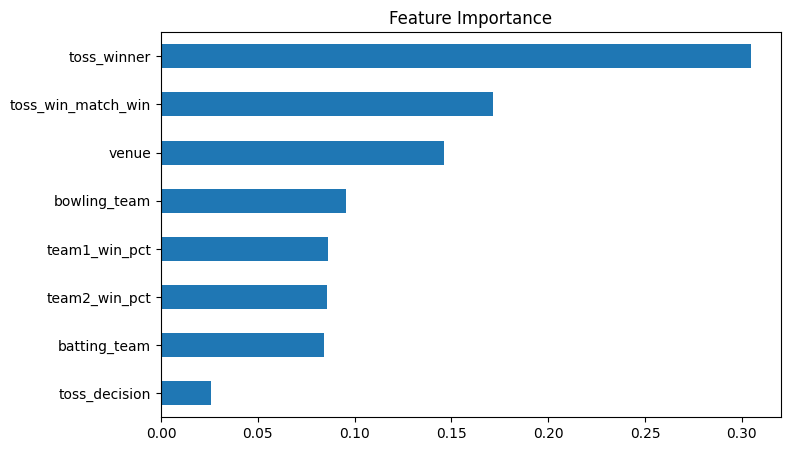

In [24]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values()

plt.figure(figsize=(8,5))
importance.plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [26]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)[0]

if prediction == 1:
    print("Predicted Winner: Batting Team")
else:
    print("Predicted Winner: Bowling Team")

Predicted Winner: Bowling Team


In [43]:
from sklearn.preprocessing import LabelEncoder
import joblib

encoders = {}

categorical_cols = ['batting_team','bowling_team','venue','toss_winner','toss_decision']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)      # VERY IMPORTANT
    le.fit(df[col])                    # fit on strings
    df[col] = le.transform(df[col])    # transform
    encoders[col] = le

In [44]:
import os

os.makedirs('../data/processed', exist_ok=True)

In [45]:
import joblib

joblib.dump(rf, '../data/processed/ipl_model.pkl')
joblib.dump(encoders, '../data/processed/encoders.pkl')

['../data/processed/encoders.pkl']

In [33]:
import os

print(os.listdir('../data/processed'))

['encoders.pkl', 'ipl_cleaned.csv', 'ipl_features.csv', 'ipl_model.pkl']


In [46]:
print(encoders['batting_team'].classes_)

['Chennai Super Kings' 'Delhi Capitals' 'Gujarat Lions' 'Gujarat Titans'
 'Kings XI Punjab' 'Kochi Tuskers Kerala' 'Kolkata Knight Riders'
 'Lucknow Super Giants' 'Mumbai Indians' 'Pune Warriors' 'Punjab Kings'
 'Rajasthan Royals' 'Rising Pune Supergiant' 'Rising Pune Supergiants'
 'Royal Challengers Bangalore' 'Royal Challengers Bengaluru'
 'Sunrisers Hyderabad']


In [41]:
df = pd.read_csv('../data/processed/ipl_features.csv')

In [42]:
print(df['batting_team'].head())

0          Kolkata Knight Riders
1    Royal Challengers Bangalore
2            Chennai Super Kings
3                Kings XI Punjab
4               Rajasthan Royals
Name: batting_team, dtype: str
